# Employee Performance
    The purpose of this project is to do the hidden trend analysis and pattern recognition over a larger dataset in an IT firm to know the pulse of employees and effects of their educational history, average experience level, previous performance etc. over their current performance. The result of this analysis will be helpful to create a machine learning model to predict other possibilities regarding the performance of employees. This can assist the higher management in taking decisions to improve policies for productivity with better HR strategy.

In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
ss = StandardScaler()
from sklearn.model_selection import train_test_split,GridSearchCV
from imblearn.over_sampling import SMOTE
ov = SMOTE()
import warnings 
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("/kaggle/input/datasets/assadmehboob/extended-employee-performance/Extended_Employee_Performance_and_Productivity_Data.csv")
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

## Data Cleaning

In [27]:
df = df.drop(columns=["Employee_ID","Hire_Date"])

In [28]:
df.duplicated().sum()

np.int64(0)

## EDA

In [29]:
df_num = df.select_dtypes(["number"])
df_text = df.select_dtypes(exclude=["number"])

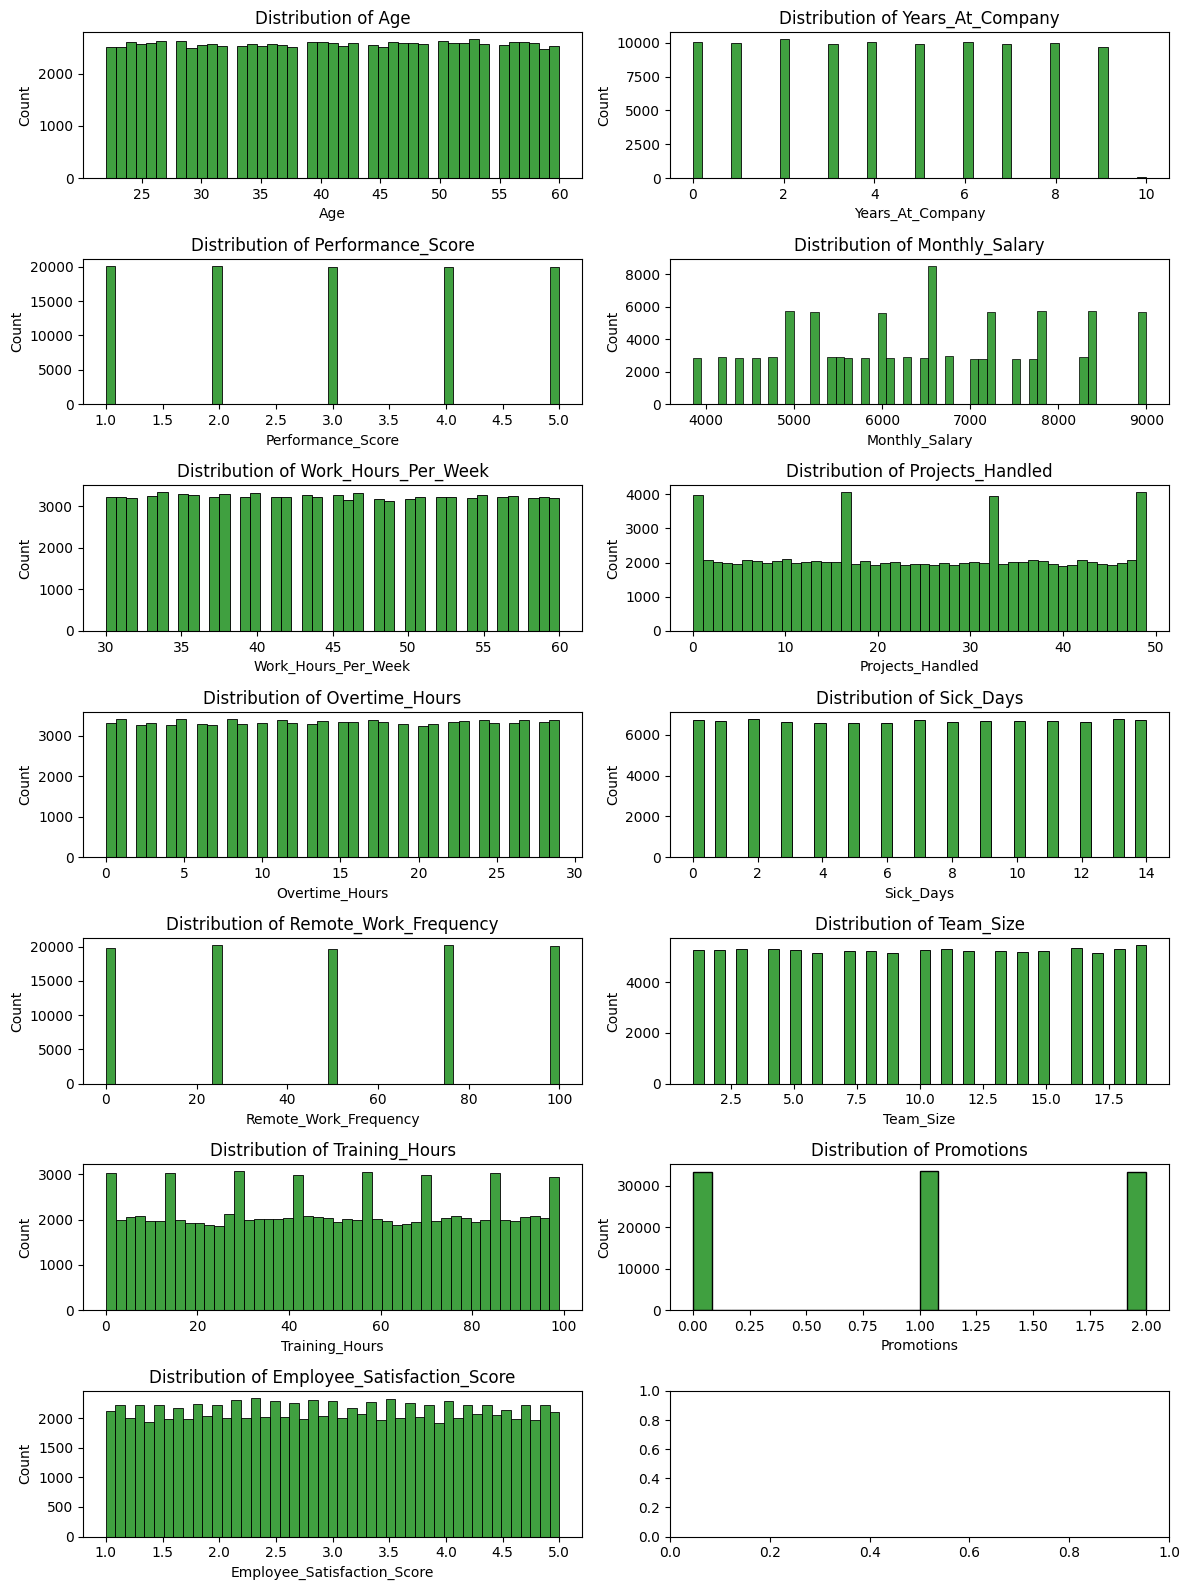

In [30]:
fig, axes = plt.subplots(7,2, figsize=(12,16))
axes = axes.flatten()

for i, col in enumerate(df_num):
    sns.histplot(data=df, x=col, color="green", edgecolor="black", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")


plt.tight_layout()
plt.show()

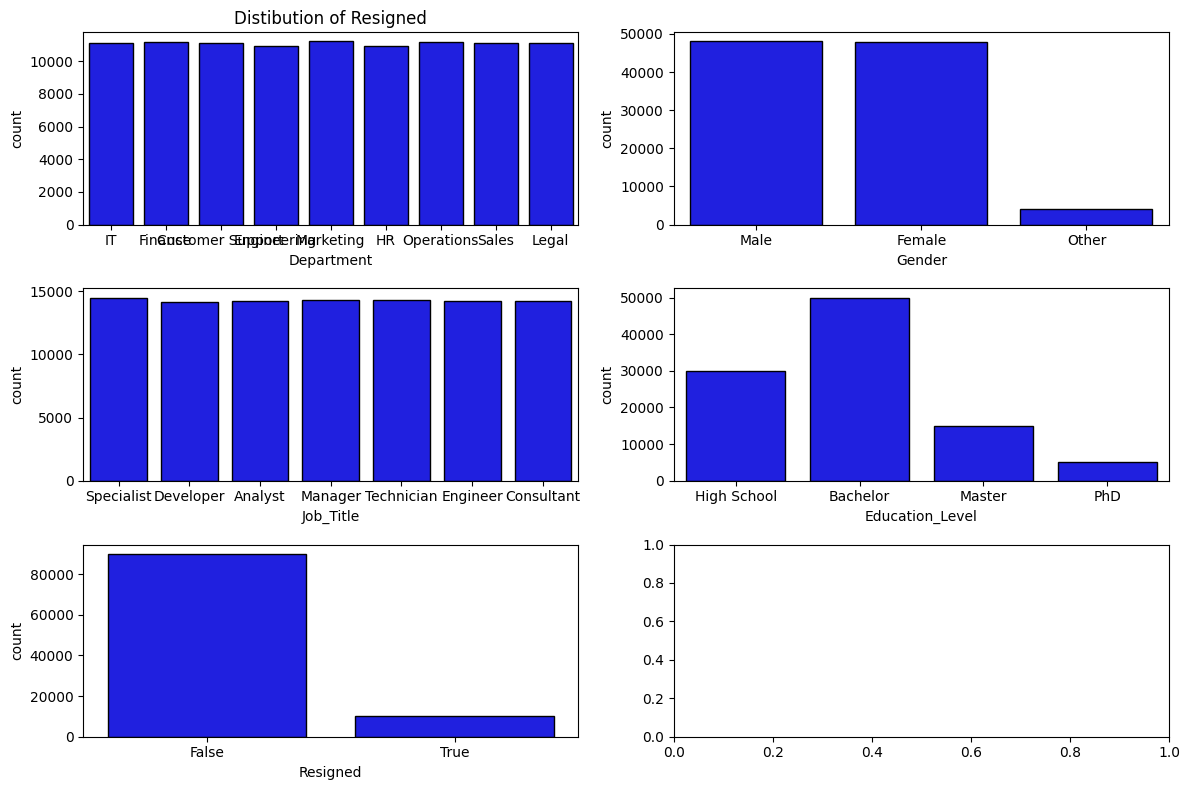

In [31]:
fig, axes = plt.subplots(3,2,figsize=(12,8))
axes = axes.flatten()

for i , col in enumerate(df_text):
    sns.countplot(data=df , x=col, color="blue",edgecolor="black",ax= axes[i])
    axes[0].set_title(f"Distibution of {col}")

plt.tight_layout()
plt.show()

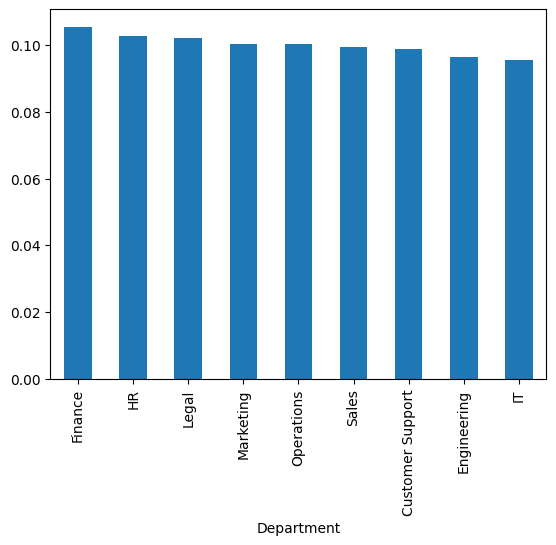

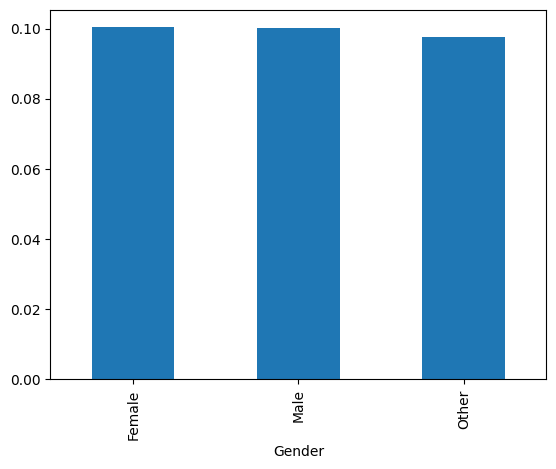

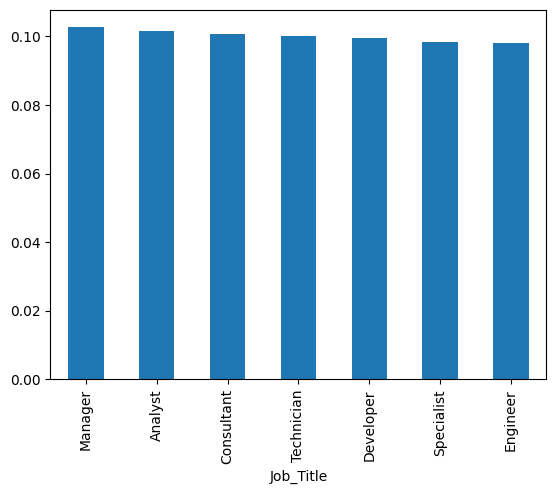

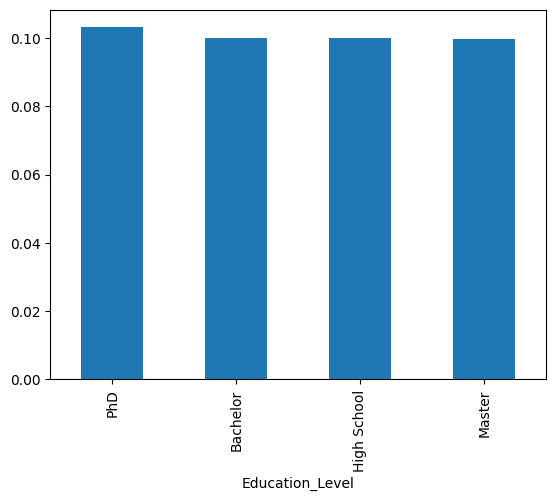

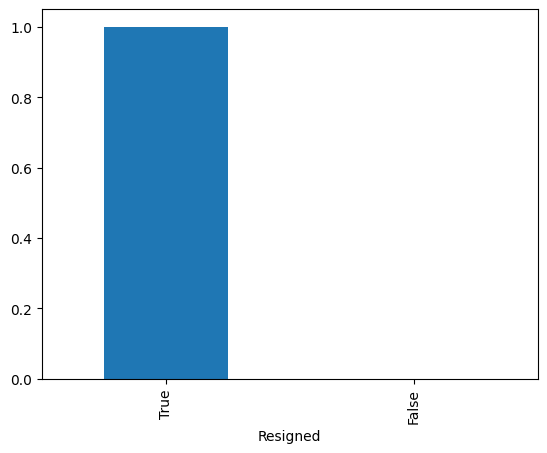

In [32]:
for col in df_text:
    df.groupby(col)["Resigned"].mean().sort_values(ascending=False).plot(kind="bar")
    plt.show()

## Data Preprocessing

In [33]:
df["Resigned"]=le.fit_transform(df["Resigned"])
df["Department"]=le.fit_transform(df["Department"])

In [34]:
df.select_dtypes("number").corr()["Resigned"]

Department                     0.000361
Age                            0.003519
Years_At_Company               0.000784
Performance_Score             -0.002714
Monthly_Salary                -0.001524
Work_Hours_Per_Week            0.000145
Projects_Handled              -0.001713
Overtime_Hours                 0.002383
Sick_Days                      0.001711
Remote_Work_Frequency          0.007205
Team_Size                     -0.000932
Training_Hours                 0.001172
Promotions                    -0.000743
Employee_Satisfaction_Score   -0.002830
Resigned                       1.000000
Name: Resigned, dtype: float64

In [35]:
df=df.drop(columns=['Department', 'Gender', 'Job_Title', 'Years_At_Company',
       'Education_Level','Work_Hours_Per_Week', 'Team_Size',"Training_Hours", 'Promotions'])

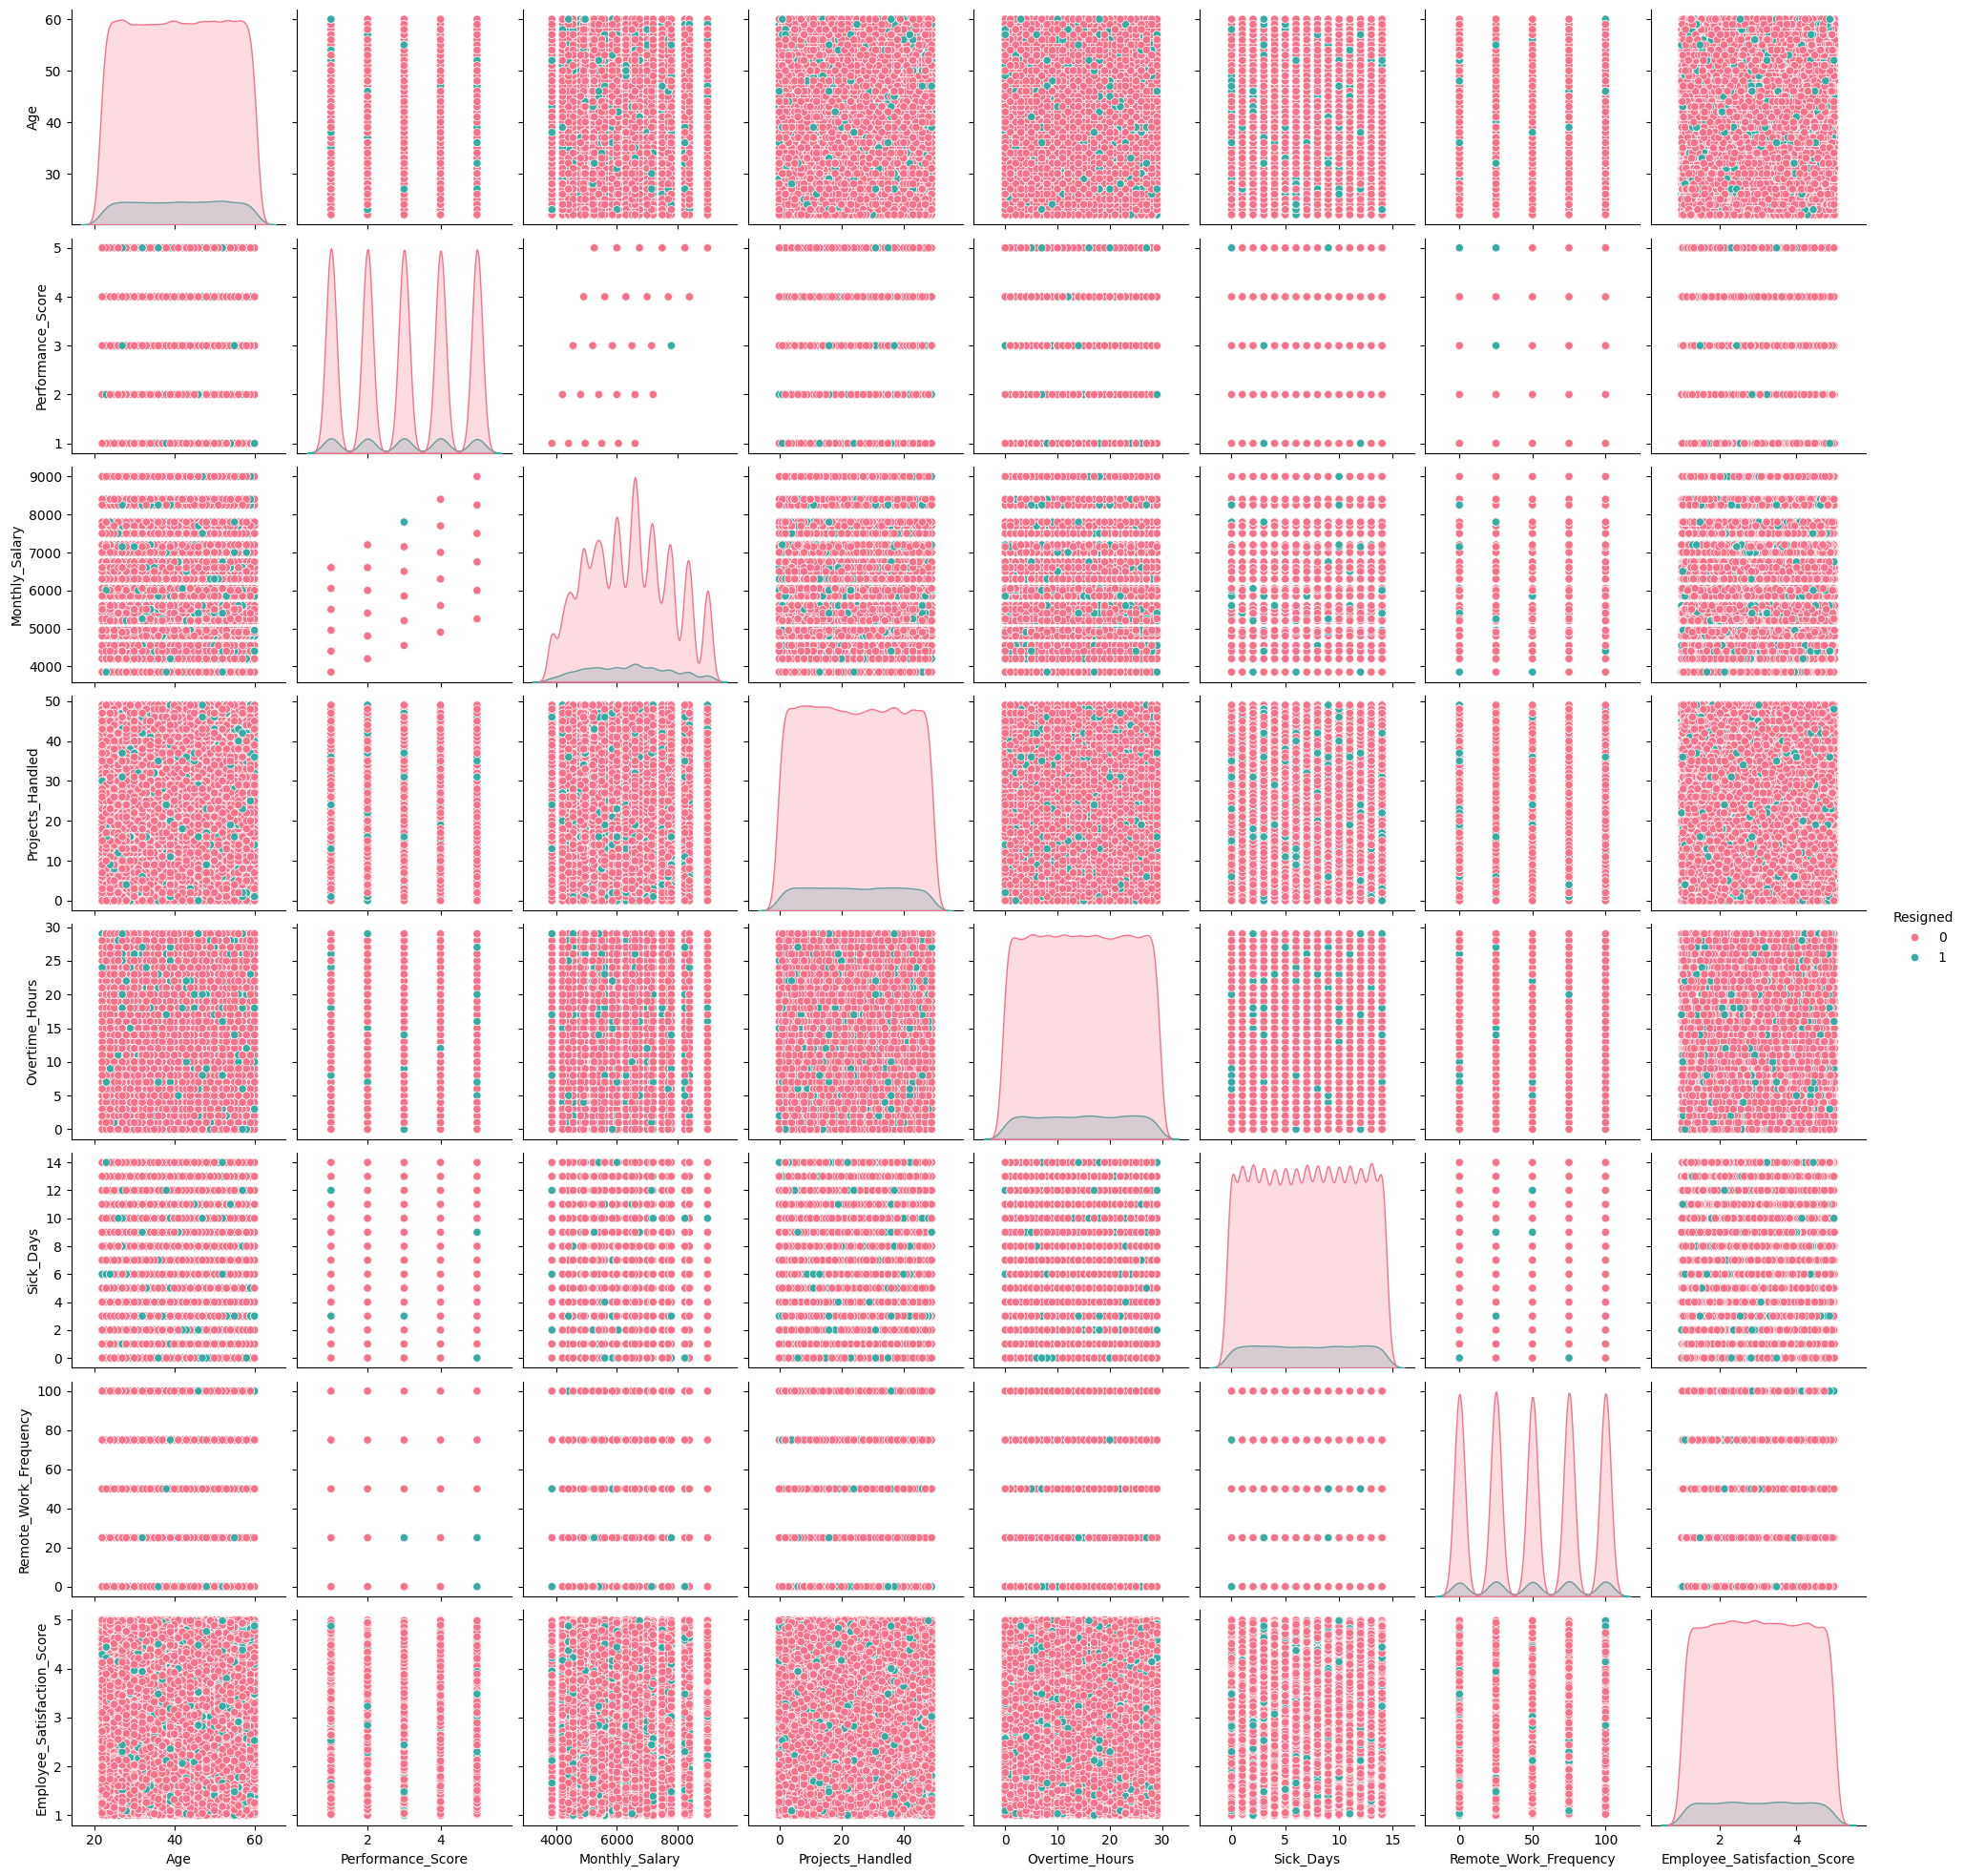

In [36]:
sns.pairplot(data=df, hue='Resigned', palette='husl', diag_kind='kde')
plt.show()

In [37]:
df.columns

Index(['Age', 'Performance_Score', 'Monthly_Salary', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency',
       'Employee_Satisfaction_Score', 'Resigned'],
      dtype='object')

In [38]:
x = df.drop(columns="Resigned")
y = df['Resigned']

In [39]:
x,y = ov.fit_resample(x,y)

In [40]:
x = ss.fit_transform(x)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x = pca.fit_transform(x)


In [41]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

## Model Selection

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [43]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)
lr_preds = lr.predict(x_train)
print(accuracy_score(y_test,lr_pred))
print(accuracy_score(y_train,lr_preds))

0.5187798644293811
0.5231622958106457


In [44]:
from sklearn.ensemble import RandomForestClassifier
for i in range(10,30,4):
    rfc = RandomForestClassifier(max_depth=i,min_samples_leaf=j)
    rfc.fit(x_train,y_train)
    rfc_pred = rfc.predict(x_test)
    print(accuracy_score(y_test,rfc_pred))
    rfc_preds = rfc.predict(x_train)
    print(accuracy_score(y_train,rfc_preds))
    print(30*"x")

0.6309034337148572
0.6337301366818535
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
0.6600733414823869
0.6853261473497055
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
0.7019668852094677
0.7648072008000889
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
0.734914990554506
0.8245499499944439
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
0.762223580397822
0.8835634514946105
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [49]:
from sklearn.neighbors import KNeighborsClassifier
for i in range(3,10,2):
    knc = KNeighborsClassifier(n_neighbors=i,metric='manhattan')
    knc.fit(x_train,y_train)
    knc_pred = knc.predict(x_test)
    print(accuracy_score(y_test,knc_pred))
    knc_preds = knc.predict(x_train)
    print(accuracy_score(y_train,knc_preds))
    print(10*f"{i}")

0.8022835870652295
0.8946619068785421
3333333333
0.7850594510501167
0.8546435715079453
5555555555
0.7721691299033225
0.8309673297033003
7777777777
0.7621957995332814
0.8136181797977553
9999999999


In [46]:
from sklearn.ensemble import GradientBoostingClassifier
for i in range(100,200,50):
    gbc = GradientBoostingClassifier(n_estimators=i)
    gbc.fit(x_train,y_train)
    gbc_pred = gbc.predict(x_test)
    print(accuracy_score(y_test,gbc_pred))
    gbc_preds = gbc.predict(x_train)
    print(accuracy_score(y_train,gbc_preds))

0.6335981775752861
0.6345218913212579
0.6418768752083565
0.6420366151794644


In [47]:
from xgboost import XGBClassifier
for i in range(100,200,50):
    xgb = XGBClassifier(n_estimators=i)
    xgb.fit(x_train,y_train)
    xgb_pred = xgb.predict(x_test)
    print(accuracy_score(y_test,xgb_pred))
    xgb_preds = xgb.predict(x_train)
    print(accuracy_score(y_train,xgb_preds))

0.6825758417601956
0.721809367707523
0.6949661073452605
0.7458606511834648


### Best Model 
    KNeighborsClassifier is the best Model for this data set 77% of accuraccy. 

In [50]:
knc = KNeighborsClassifier(n_neighbors=7,metric='manhattan')
knc.fit(x_train,y_train)
knc_pred = knc.predict(x_test)
print(accuracy_score(y_test,knc_pred))
knc_preds = knc.predict(x_train)
print(accuracy_score(y_train,knc_preds))

0.7721691299033225
0.8309673297033003


## conclusion
    The data science project was used to identify the most significant trends of human resource management of the IT industry through analysis of various work-related metrics to improve their decision-making. The project begun with preprocessing the dataset which ensured its high quality by removing the irrelevant features. Moreover, the exploratory data analysis results showed that the rest attributes were distributed equally, however, the monthly salary, training hours, and projects impacted to the employee significantly with a large variance. Additionally, the demographic correlation with employee information revealed that the majority of workforce have bachelor’s degree and their average agreement to stay was high even though the gender minority groups were present. The researchers detected that the age, performance scores, monthly salary, overtime, frequency of remote work, and average satisfaction are the significant factors that influence the resignation of employees. Even though the resignation ratio was constantly similar for different features, the selected values had a greater enhancing effect on the employee leaving the organization. The K-Nearest Neighbors (KNN) model was found out to be the best predictor with almost no overfitting compared to other tried algorithms. The accuracy score was 77 percent. The analysis results provided the management with a data-based opportunity to improve human resource management, employee satisfaction, and productivity through their policies.